# Chương 3 — Text Classification & Sentiment Analysis
Notebook này được thiết kế để sinh viên thực hành xây dựng và so sánh nhiều hệ thống phân loại văn bản:

1. **Rule-based baseline**
2. **TF-IDF + Multinomial Naive Bayes**
3. **TF-IDF + Logistic Regression**
4. **TF-IDF + Linear SVM**
5. **Decision Tree / Random Forest** ở mức tham khảo
6. **Lexicon-based Sentiment Analysis**
7. **PhoBERT / ViSoBERT** ở mức mở rộng

### Mục tiêu
Sinh viên phải trả lời được:

- Văn bản được biến thành vector như thế nào?
- Vì sao TF-IDF thường mạnh hơn Bag of Words thô?
- Naive Bayes, Logistic Regression và SVM khác nhau ra sao?
- Accuracy có đủ để đánh giá mô hình không?
- Khi dữ liệu mất cân bằng nên dùng metric nào?
- Vì sao sentiment analysis khó với phủ định, sarcasm, emoji và domain shift?
- Mô hình pretrained cải thiện điểm gì và đánh đổi điều gì?

> Notebook có dữ liệu demo nhỏ nhúng sẵn để chạy độc lập. Tuy nhiên, khi thực hiện bài thực hành sinh viên cần thay bằng UIT-VSFC, UIT-VSMEC hoặc dữ liệu tương đương.

# 0. Chuẩn bị môi trường

Notebook dùng các thư viện phổ biến:
- pandas
- numpy
- scikit-learn
- matplotlib


In [325]:
import re
import time
import math
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


# 1. Dữ liệu mẫu

Ta dùng một dataset nhỏ gồm:
- `text`: câu tiếng Việt
- `sentiment`: `positive / negative / neutral`
- `topic`: `teaching / facility / administration / technology`

Mục đích:
- sentiment → bài toán **multiclass classification**
- topic → một bài toán classification khác trên cùng văn bản
- về sau có thể mở rộng thành multilabel.

In [326]:
positive_templates = [
    ("Giảng viên dạy rất dễ hiểu và nhiệt tình", "teaching"),
    ("Bài giảng rõ ràng, ví dụ thực tế rất hữu ích", "teaching"),
    ("Phòng học sạch sẽ và máy lạnh hoạt động tốt", "facility"),
    ("Thư viện rộng, yên tĩnh và có nhiều tài liệu", "facility"),
    ("Phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration"),
    ("Thủ tục đăng ký môn học khá thuận tiện", "administration"),
    ("Hệ thống học trực tuyến chạy ổn định và dễ sử dụng", "technology"),
    ("Website mới nhanh hơn và ít lỗi hơn trước", "technology"),
    ("Mình rất hài lòng với môn học này", "teaching"),
    ("Wifi trong trường hôm nay rất tốt", "technology"),
]

negative_templates = [
    ("Giảng viên giảng quá nhanh nên tôi không theo kịp", "teaching"),
    ("Bài tập quá nhiều nhưng hướng dẫn chưa rõ", "teaching"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
]

neutral_templates = [
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

augment_prefix = [
    "", "Theo mình, ", "Cá nhân mình thấy ", "Hôm nay ", "Trong học kỳ này, "
]
augment_suffix = [
    "", ".", "!", " :)", " 👍", " 😐"
]

rows = []
for sentiment, templates in [
    ("positive", positive_templates),
    ("negative", negative_templates),
    ("neutral", neutral_templates),
]:
    for base, topic in templates:
        for i in range(4):
            text = random.choice(augment_prefix) + base + random.choice(augment_suffix)
            rows.append((text, sentiment, topic))

df = pd.DataFrame(rows, columns=["text", "sentiment", "topic"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
display(df.head(10))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())

(120, 3)


,text,sentiment,topic
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,teaching
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,facility
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,technology
5,Hôm nay Website thường xuyên lỗi khi đăng ký m...,negative,technology
6,Cá nhân mình thấy Tôi không hài lòng với cách ...,negative,teaching
7,"Trong học kỳ này, Phòng học sạch sẽ và máy lạn...",positive,facility
8,"Theo mình, Giảng viên giảng quá nhanh nên tôi ...",negative,teaching
9,"Theo mình, Hệ thống học trực tuyến có phiên bả...",neutral,technology



Sentiment distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64

Topic distribution:
topic
teaching          36
technology        36
facility          24
administration    24
Name: count, dtype: int64


## Task 1 — Bài toán phân loại

### Code mẫu
- sentiment: **multiclass** với 3 nhãn.
- topic: **multiclass** với 4 nhãn.

### Yêu cầu sinh viên
1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.
2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.
3. Đề xuất một taxonomy **hierarchical classification**:
   - `academic`
     - teaching
     - curriculum
   - `service`
     - administration
     - facility
4. Giải thích khác biệt giữa:
   - text classification,
   - sequence labeling.

### TODO

In [327]:
from pathlib import Path

DATA_DIR = Path(r"C:/Users/khanh/Downloads/data")
DATA_FILES = {"train": DATA_DIR / "train.xlsx",
              "validation": DATA_DIR / "valid.xlsx",
              "test": DATA_DIR / "test.xlsx"}

EXPECTED_EMOTIONS = {"Anger", "Disgust", "Enjoyment", "Fear",
                     "Other", "Sadness", "Surprise"}
POSITIVE_EMOTIONS = {"Enjoyment"}

def load_emotion_split(file_path, split_name):
    #Đọc một split và chỉ giữ các cột có ý nghĩa cho bài toán
    raw_data = pd.read_excel(file_path)
    required_columns = {"Emotion", "Sentence"}
    missing_columns = required_columns - set(raw_data.columns)
    if missing_columns:
        raise ValueError(f"{file_path.name} thiếu cột: {sorted(missing_columns)}")

    data = (raw_data.loc[:, ["Emotion", "Sentence"]].rename(columns={"Emotion": "emotion", "Sentence": "text"}).copy())
    if data.isna().any().any():
        raise ValueError(f"{file_path.name} có giá trị thiếu.")

    unknown_emotions = set(data["emotion"].unique()) - EXPECTED_EMOTIONS
    if unknown_emotions:
        raise ValueError(f"{file_path.name} có nhãn lạ: {sorted(unknown_emotions)}")
    data.insert(0, "split", split_name)
    return data

emotion_splits = {split_name: load_emotion_split(file_path, split_name)
    for split_name, file_path in DATA_FILES.items()}
for split_name, split_data in emotion_splits.items():
    print(f"{split_name}: {len(split_data)} câu")


train: 5548 câu
validation: 686 câu
test: 693 câu


In [328]:
# # TODO 1: tạo cột binary_sentiment
# df["binary_sentiment"] = df["sentiment"].apply(
#     lambda x: "positive" if x == "positive" else "non_positive"
# )

# display(df[["text", "sentiment", "binary_sentiment"]].head())

# # TODO 2:
# # - tạo ví dụ multilabel
# # - đề xuất cấu trúc hierarchical label

In [386]:
def add_binary_sentiment(data):
    #Ánh xạ Enjoyment thành positive, các cảm xúc khác thành non_positive
    result = data.copy()
    is_positive = result["emotion"].isin(POSITIVE_EMOTIONS)
    result["binary_sentiment"] = np.where(is_positive, "positive", "non_positive")
    return result

task1_splits = {split_name: add_binary_sentiment(split_data)
                for split_name, split_data in emotion_splits.items()}

task1_train = task1_splits["train"]
task1_validation = task1_splits["validation"]
task1_test = task1_splits["test"]

for split_name in ["train", "validation", "test"]:
    print(f"\nCác câu trong tập {split_name}:")
    display(task1_splits[split_name][["text", "emotion", "binary_sentiment"]].head(10))

# Chỉ ghép tạm để thống kê; không dùng bảng này để fit mô hình
task1_all = pd.concat(task1_splits.values(), ignore_index=True)
binary_distribution = (task1_all.groupby(["split", "binary_sentiment"], observed=True).size().rename("count").reset_index())
print("\nPhân phối nhãn nhị phân theo từng tập:")
display(binary_distribution)

# Giữ tương thích với các cell minh họa phía sau của notebook gốc
df["binary_sentiment"] = np.where(df["sentiment"].eq("positive"), "positive", "non_positive")


Các câu trong tập train:


,text,emotion,binary_sentiment
0,cho mình xin bài nhạc tên là gì với ạ,Other,non_positive
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust,non_positive
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust,non_positive
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment,positive
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment,positive
5,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,Anger,non_positive
6,một lí do trog muôn vàn lí do,Other,non_positive
7,thật hay đùa ác vậy . không thể tin được,Surprise,non_positive
8,"ko phải con mình , mà xem còn thấy đau như vậy...",Anger,non_positive
9,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,Sadness,non_positive



Các câu trong tập validation:


,text,emotion,binary_sentiment
0,"tính tao tao biết , chẳng có chuyện gì có thể ...",Other,non_positive
1,"lại là lào cai , tự hào quê mình quá :))",Enjoyment,positive
2,bị từ chối rồi,Sadness,non_positive
3,tam đảo trời đẹp các mem à,Enjoyment,positive
4,đọc bình luận của thằng đó không thiếu chữ nào 😂😂,Other,non_positive
5,crush tao vẫn còn trinh nhé 😘,Enjoyment,positive
6,nó nói không đúg ư . đg của nhà bà ư . nó đóg ...,Anger,non_positive
7,gap kiểu này chắc đái ra quần quá,Fear,non_positive
8,yêu em mọa mọa 😘😘,Enjoyment,positive
9,có ai như tao không đọc đề thì quen nhưng lại ...,Sadness,non_positive



Các câu trong tập test:


,text,emotion,binary_sentiment
0,người ta có bạn bè nhìn vui thật,Sadness,non_positive
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,non_positive
2,kinh vãi 😡,Disgust,non_positive
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,non_positive
4,bố không thích nộp đấy mày thích ý kiến không,Anger,non_positive
5,bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân...,Other,non_positive
6,per khi nào bạn có bằng xe ôtô thì bạn mới hiể...,Other,non_positive
7,một hành động đẹp đầy tính nhân văn ☺️☺️,Enjoyment,positive
8,anh nhỏ nhẹ xin 100k rồi trước khi đi còn chào...,Other,non_positive
9,per trình mày vẫn còn thấp chán =)),Other,non_positive



Phân phối nhãn nhị phân theo từng tập:


,split,binary_sentiment,count
0,test,non_positive,500
1,test,positive,193
2,train,non_positive,3990
3,train,positive,1558
4,validation,non_positive,472
5,validation,positive,214


2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.

In [ ]:
SOURCE_TEXTS = {"teaching": ("giáo viên tiếng anh ở cấp thcs cực kì chán , phát âm sai bét , "
                 "giao tiếp tiếng anh thì cứ ừ à ."),
                 "facility": "đằng nào thì điều hòa vẫn bật mà ."}

train_data = emotion_splits["train"]
source_records = []
for source_topic, source_text in SOURCE_TEXTS.items():
    matched_rows = train_data[train_data["text"].eq(source_text)]
    if len(matched_rows) != 1:
        raise ValueError(f"Cần đúng 1 câu nguồn cho {source_topic}, tìm thấy {len(matched_rows)}")

    source_row = matched_rows.iloc[0]
    source_records.append(
        {
            "split": source_row["split"],
            "excel_row": int(source_row.name) + 2,
            "text": source_row["text"],
            "emotion": source_row["emotion"],
            "source_topic": source_topic
        }
    )

multilabel_sources = pd.DataFrame(source_records)
multilabel_text = " ".join(multilabel_sources["text"])
multilabel_example = pd.DataFrame(
    [
        {
            "text": multilabel_text,
            "topic_labels": ["teaching", "facility"],
            "teaching": 1,
            "facility": 1,
            "annotation_type": "synthetic_from_train",
        }
    ]
)
print("Hai câu nguồn lấy trực tiếp từ train.xlsx:")
display(multilabel_sources)
print("Ví dụ multilabel được tổng hợp từ hai câu nguồn:")
display(multilabel_example)

Hai câu nguồn lấy trực tiếp từ train.xlsx:


,split,excel_row,text,emotion,source_topic
0,train,2503,"giáo viên tiếng anh ở cấp thcs cực kì chán , p...",Other,teaching
1,train,1414,đằng nào thì điều hòa vẫn bật mà .,Other,facility


Ví dụ multilabel được tổng hợp từ hai câu nguồn:


,text,topic_labels,teaching,facility,annotation_type
0,"giáo viên tiếng anh ở cấp thcs cực kì chán , p...","[teaching, facility]",1,1,synthetic_from_train


3. Hierarchical classification\
Taxonomy có hai tầng. academic là nhãn cha của teaching và curriculum\
 service là nhãn cha của administration và facility.

In [331]:
hierarchical_taxonomy = {"academic": ["teaching", "curriculum"],
                         "service": ["administration", "facility"]}

taxonomy_table = pd.DataFrame(
    [
        {"level_1": parent, "level_2": child, "path": f"{parent}/{child}"}
        for parent, children in hierarchical_taxonomy.items()
        for child in children
    ]
)
display(taxonomy_table)

,level_1,level_2,path
0,academic,teaching,academic/teaching
1,academic,curriculum,academic/curriculum
2,service,administration,service/administration
3,service,facility,service/facility


4. Khác biệt giữa text classification và sequence labeling:\
*text classification gán nhãn trên toàn bộ câu, đoạn, tài liệu\
-đầu ra là 1 nhãn hoặc 1 tập cho cả văn bản\
-feature đại diện cho cả document\
*sequence labeling gán nhãn từng token, từng từ trong chuỗi\
-đầu ra 1 nhãn cho từng từ, token\
-feature đại diện cho từng token + context của câu

# 2. Tiền xử lý tối thiểu

Với các mô hình truyền thống, ta thường:
- Unicode normalization
- lowercase
- chuẩn hóa khoảng trắng

Không nên xóa quá nhiều thông tin khi làm sentiment:
- dấu chấm than,
- emoji,
- từ phủ định
có thể mang tín hiệu cảm xúc.

In [332]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["text"].map(normalize_text)
display(df[["text", "text_norm"]].head())

,text,text_norm
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,cá nhân mình thấy bài tập quá nhiều nhưng hướn...
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...","trong học kỳ này, bài giảng rõ ràng, ví dụ thự..."
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,cá nhân mình thấy nhà vệ sinh chưa sạch và thi...
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,cá nhân mình thấy hệ thống học trực tuyến chạy...


## Task 2: Cải tiến preprocessing
1. So sánh:
   - giữ dấu câu,
   - bỏ dấu câu.
2. So sánh:
   - giữ emoji,
   - bỏ emoji.
3. Thử chuẩn hóa:
   - `ko`, `k`, `khum` → `không`
   - `dc` → `được`
4. Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.

In [333]:
task2_data = task1_train[["text", "emotion"]].copy()
print(f"Số câu dùng cho Task 2: {len(task2_data)}")
display(task2_data.head(10))

Số câu dùng cho Task 2: 5548


,text,emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment
5,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,Anger
6,một lí do trog muôn vàn lí do,Other
7,thật hay đùa ác vậy . không thể tin được,Surprise
8,"ko phải con mình , mà xem còn thấy đau như vậy...",Anger
9,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,Sadness


1. giữ dấu câu và bỏ dấu câu

In [334]:
def contains_punctuation(text):
    return any(unicodedata.category(character).startswith("P")
        for character in str(text))

def remove_punctuation(text):
    normalized = normalize_text(text)
    characters = [" " if unicodedata.category(character).startswith("P") else character
        for character in normalized]
    return re.sub(r"\s+", " ", "".join(characters)).strip()

punctuation_mask = task2_data["text"].map(contains_punctuation)
punctuation_comparison = task2_data.loc[punctuation_mask].copy()

punctuation_comparison["keep_punctuation"] = (punctuation_comparison["text"].map(normalize_text))
punctuation_comparison["remove_punctuation"] = (punctuation_comparison["text"].map(remove_punctuation))

print(f"Số câu train có dấu câu: {punctuation_mask.sum()}")
display(punctuation_comparison[["emotion", "keep_punctuation", "remove_punctuation"]].head(10))

Số câu train có dấu câu: 3217


,emotion,keep_punctuation,remove_punctuation
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,cho đáng đời con quỷ về nhà lôi con nhà mày ra...
2,Disgust,lo học đi . yêu đương lol gì hay lại thích học...,lo học đi yêu đương lol gì hay lại thích học s...
3,Enjoyment,uớc gì sau này về già vẫn có thể như cụ này :)),uớc gì sau này về già vẫn có thể như cụ này
4,Enjoyment,mỗi lần có video của con là cứ coi đi coi lại ...,mỗi lần có video của con là cứ coi đi coi lại ...
5,Anger,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...,thằng kia sao mày bắt vợ với bồ tao dọn thế ki...
7,Surprise,thật hay đùa ác vậy . không thể tin được,thật hay đùa ác vậy không thể tin được
8,Anger,"ko phải con mình , mà xem còn thấy đau như vậy...",ko phải con mình mà xem còn thấy đau như vậy h...
9,Sadness,per nghe đi rồi khóc 1 trận cho thoải mái . đừ...,per nghe đi rồi khóc 1 trận cho thoải mái đừng...
12,Other,trời nắng nóng thế này mình muốn bán nước khôn...,trời nắng nóng thế này mình muốn bán nước khôn...
14,Disgust,mấy thằng củ lol việt nam nhảm nhí :)),mấy thằng củ lol việt nam nhảm nhí


2. giữ emoji và bỏ emoji

In [335]:
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F1E6-\U0001F1FF"  # cờ
    "\U0001F300-\U0001FAFF"  # emoji và pictograph
    "\u2600-\u26FF"          # ký hiệu khác
    "\u2700-\u27BF"          
    "]",
    flags=re.UNICODE,
)

def contains_emoji(text):
    return bool(EMOJI_PATTERN.search(str(text)))

def remove_emoji(text):
    normalized = normalize_text(text)
    without_emoji = EMOJI_PATTERN.sub(" ", normalized)
    without_emoji = without_emoji.replace("\u200d", "").replace("\ufe0f", "")
    return re.sub(r"\s+", " ", without_emoji).strip()


emoji_mask = task2_data["text"].map(contains_emoji)
emoji_comparison = task2_data.loc[emoji_mask].copy()
emoji_comparison["keep_emoji"] = emoji_comparison["text"].map(normalize_text)
emoji_comparison["remove_emoji"] = emoji_comparison["text"].map(remove_emoji)

print(f"Số câu train có emoji: {emoji_mask.sum()}")
display(emoji_comparison[["emotion", "keep_emoji", "remove_emoji"]].head(10))

Số câu train có emoji: 957


,emotion,keep_emoji,remove_emoji
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,cho đáng đời con quỷ . về nhà lôi con nhà mày ...
8,Anger,"ko phải con mình , mà xem còn thấy đau như vậy...","ko phải con mình , mà xem còn thấy đau như vậy..."
11,Disgust,đòn tấn công cực gắt và cục sút của anh 😂😂😂,đòn tấn công cực gắt và cục sút của anh
19,Enjoyment,sau em này mà làm cô giáo ngồi kể chuyện hs lạ...,sau em này mà làm cô giáo ngồi kể chuyện hs lạ...
22,Enjoyment,chả mong gì nhiều chỉ mong về già được như hai...,chả mong gì nhiều chỉ mong về già được như hai...
24,Sadness,mày định lướt qua rồi nhưng khi đọc bình luận ...,mày định lướt qua rồi nhưng khi đọc bình luận ...
27,Fear,từ đầu năm giờ chắc chụp 10 lần rồi huhu sợ qu...,từ đầu năm giờ chắc chụp 10 lần rồi huhu sợ quá
32,Sadness,"hồi học lớp 5 bảo bố đi mua sgk cho , xong bố ...","hồi học lớp 5 bảo bố đi mua sgk cho , xong bố ..."
39,Enjoyment,khi nào phường có chế độ phát chồng khi mang t...,khi nào phường có chế độ phát chồng khi mang t...
40,Anger,đéo được tích sự gì 😂,đéo được tích sự gì


3. chuẩn hóa teencode

In [336]:
TEENCODE_MAP = {
    "ko": "không",
    "k": "không",
    "khum": "không",
    "dc": "được",
}
TEENCODE_PATTERN = re.compile(r"\b(?:ko|k|khum|dc)\b",flags=re.IGNORECASE,)
def replace_teencode(match):
    #Trả về dạng đầy đủ của một từ teencode đã khớp
    teencode = match.group(0).lower()
    return TEENCODE_MAP[teencode]

def normalize_teencode(text):
    #Chuẩn hóa văn bản và thay các từ teencode có trong bảng ánh xạ
    normalized = normalize_text(text)
    return TEENCODE_PATTERN.sub(replace_teencode, normalized)

def contains_teencode(text):
    #Kiểm tra văn bản có chứa teencode trong bảng ánh xạ hay không
    return bool(TEENCODE_PATTERN.search(str(text)))

teencode_mask = task2_data["text"].map(contains_teencode)
teencode_comparison = task2_data.loc[teencode_mask].copy()
teencode_comparison["before"] = teencode_comparison["text"].map(normalize_text)
teencode_comparison["after"] = teencode_comparison["text"].map(normalize_teencode)

print(f"Số câu train chứa teencode trong bảng ánh xạ: {teencode_mask.sum()}")
display(teencode_comparison[["emotion", "before", "after"]].head(10))

Số câu train chứa teencode trong bảng ánh xạ: 27


,emotion,before,after
8,Anger,"ko phải con mình , mà xem còn thấy đau như vậy...","không phải con mình , mà xem còn thấy đau như ..."
104,Disgust,k phải là trời không cho mày yêu . vì m quá ng...,không phải là trời không cho mày yêu . vì m qu...
471,Anger,tô ́ tao nhất là chết luôn đi ko chết sau này ...,tô ́ tao nhất là chết luôn đi không chết sau n...
473,Sadness,buôn bỏ nhưng tình cảm ko thuoc về mình nua . ...,buôn bỏ nhưng tình cảm không thuoc về mình nua...
1441,Disgust,"tao bảo 99 , 99999 % là mấy ông ngoài bắc và k...","tao bảo 99 , 99999 % là mấy ông ngoài bắc và k..."
1517,Disgust,k chăm được thì đừng nuôi nhìn tội quá ??,không chăm được thì đừng nuôi nhìn tội quá ??
1836,Disgust,ko biết đúng sai như thế nào giờ báo đài ai cũ...,không biết đúng sai như thế nào giờ báo đài ai...
2088,Fear,ko sợ gì chỉ sợ con ml ý 😞,không sợ gì chỉ sợ con ml ý 😞
2125,Anger,ko như thằng per năm ấy ngồi cạnh tao một hai ...,không như thằng per năm ấy ngồi cạnh tao một h...
2574,Fear,"k có con gì ác bằng con người , các con bé như...","không có con gì ác bằng con người , các con bé..."


4.Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.
1. Xóa từ phủ định\
vd: sản phẩm này không tốt\
từ mang sentiment là tốt => positive nhưng "không" là từ phủ định làm đảo chiều sentiment. Nếu processing xem "không" là stopword rồi xóa đi thì ý nghĩa thay đổi negative => positive\
2. Xóa dấu câu\
dấu câu chứa cường độ cảm xúc\
vd: "sản phẩm tốt." với "sản phẩm tốt!!!" => cả 2 đều là postive nhưng câu 2 thể hiện cảm xúc mạnh hơn\
Nếu preprocessing bỏ dấu câu mô hình vẫn biết câu positve nhờ từ "tốt" nhưng mất tín hiệu thế hiện mức độ positive mạnh\
Xóa dấu câu ko làm tđ nhãn nhưng làm giảm lượng thông tin sentiment\
3. Xóa emoji\
emoji quan trọng trong review, chat, comment. Nếu xóa emoji có thể mất tín hiệu thể hiện thái độ người viết\
4. chuẩn hóa teencode ko đúng\
vd: "app này ko ok 😡"\
nếu preprocessing không nhận ra "ko" có nghĩa là "không" thì câu thành "app này ok" => sentiment có thể hiểu sai ý negative -> positive\
5. xóa từ tăng cường hoặc giảm nhẹ\
1 số từ không quyết định pos/neg trực tiếp nhưng quyết định mức độ sentiment\
vd: tốt, rất tốt, cực kỳ tốt, hơi tốt mang thông tin intensity\
nếu preprocessing xóa "cực kỳ" => dịch vụ tệ vẫn mang negative nhưng mức độ cảm xúc mạnh đã mất

# 3. Chia train/test

Nguyên tắc:
- dùng cùng một split cho tất cả mô hình để so sánh công bằng;
- nên dùng `stratify=y` để giữ phân phối nhãn tương đối ổn định.

In [337]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

print("Train:", len(X_train))
print("Test :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

Train: 90
Test : 30

Train label distribution:
sentiment
positive    0.333333
negative    0.333333
neutral     0.333333
Name: proportion, dtype: float64


## Task 3: Data split và leakage
1. Tạo train / validation / test.
2. Giải thích vì sao **fit TF-IDF trên toàn bộ dataset trước khi split** là data leakage.
3. Kiểm tra duplicate / near-duplicate giữa train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split thay vì random split.

In [338]:
def prepare_task3_split(data, source_file):
    #Thêm thông tin nguồn và văn bản chuẩn hóa cho một split
    result = data.copy()
    result.insert(1, "source_file", source_file.name)
    result.insert(2, "excel_row", result.index.to_numpy() + 2)
    result["text_norm"] = result["text"].map(normalize_text)
    return result.reset_index(drop=True)

task3_splits = {}
for split_name, split_data in emotion_splits.items():
    task3_splits[split_name] = prepare_task3_split(split_data, DATA_FILES[split_name])

task3_train = task3_splits["train"]
task3_validation = task3_splits["validation"]
task3_test = task3_splits["test"]

X_train = task3_train["text_norm"]
y_train = task3_train["emotion"]
X_validation = task3_validation["text_norm"]
y_validation = task3_validation["emotion"]
X_test = task3_test["text_norm"]
y_test = task3_test["emotion"]

split_records = []
for split_name, split_data in task3_splits.items():
    split_records.append(
        {
            "split": split_name,
            "source_file": split_data["source_file"].iloc[0],
            "n_samples": len(split_data),
            "n_labels": split_data["emotion"].nunique(),
        }
    )

task3_split_summary = pd.DataFrame(split_records)
label_distribution = pd.concat(
    {
        split_name: split_data["emotion"].value_counts()
        for split_name, split_data in task3_splits.items()
    },axis=1,).fillna(0).astype(int).T
label_distribution.index.name = "split"

display(task3_split_summary)
display(label_distribution)

for split_name, split_data in task3_splits.items():
    print(f"\nCác câu mẫu trong tập {split_name}:")
    display(split_data[["text", "emotion"]].head())

,split,source_file,n_samples,n_labels
0,train,train.xlsx,5548,7
1,validation,valid.xlsx,686,7
2,test,test.xlsx,693,7


emotion,Enjoyment,Disgust,Other,Sadness,Anger,Fear,Surprise
split,,,,,,,
train,1558,1071,1021,947,391,318,242
validation,214,135,141,86,49,31,30
test,193,132,129,116,40,46,37



Các câu mẫu trong tập train:


,text,emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment



Các câu mẫu trong tập validation:


,text,emotion
0,"tính tao tao biết , chẳng có chuyện gì có thể ...",Other
1,"lại là lào cai , tự hào quê mình quá :))",Enjoyment
2,bị từ chối rồi,Sadness
3,tam đảo trời đẹp các mem à,Enjoyment
4,đọc bình luận của thằng đó không thiếu chữ nào 😂😂,Other



Các câu mẫu trong tập test:


,text,emotion
0,người ta có bạn bè nhìn vui thật,Sadness
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise
2,kinh vãi 😡,Disgust
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear
4,bố không thích nộp đấy mày thích ý kiến không,Anger


2. Ngăn data leakage khi dùng IF-IDF

In [339]:
task3_tfidf = TfidfVectorizer()
task3_X_train_tfidf = task3_tfidf.fit_transform(X_train)
task3_X_validation_tfidf = task3_tfidf.transform(X_validation)
task3_X_test_tfidf = task3_tfidf.transform(X_test)

print("TF-IDF chỉ được fit trên train.")
print("Train shape     :", task3_X_train_tfidf.shape)
print("Validation shape:", task3_X_validation_tfidf.shape)
print("Test shape      :", task3_X_test_tfidf.shape)
print("Vocabulary size:", len(task3_tfidf.vocabulary_))

TF-IDF chỉ được fit trên train.
Train shape     : (5548, 4113)
Validation shape: (686, 4113)
Test shape      : (693, 4113)
Vocabulary size: 4113


3. Kiểm tra exact duplicate và near-duplicate

In [340]:
from sklearn.neighbors import NearestNeighbors

def find_overlap(train_texts, test_texts):
    #Trả về các câu trong test xuất hiện chính xác trong train
    train_set = set(train_texts)
    return [text for text in test_texts if text in train_set]


train_test_overlap = find_overlap(X_train, X_test)
print("Exact overlap train–test:", len(train_test_overlap))
      
def find_exact_duplicates(reference_data, comparison_data, split_name):
    #Tìm các câu ở split so sánh trùng hoàn toàn với train
    reference = reference_data[["excel_row", "text_norm", "text", "emotion"]].drop_duplicates(subset="text_norm")
    reference = reference.rename(
        columns={
            "excel_row": "train_excel_row",
            "text": "train_text",
            "emotion": "train_emotion"
        }
    )
    comparison = comparison_data[["excel_row", "text_norm", "text", "emotion"]].rename(columns={"excel_row": "comparison_excel_row",
                                                                                                "text": "comparison_text",
                                                                                                "emotion": "comparison_emotion"})
    duplicates = comparison.merge(reference, on="text_norm", how="inner")
    duplicates.insert(0, "comparison_split", split_name)
    return duplicates.drop(columns="text_norm")


def find_near_duplicates(reference_data, 
                         comparison_data, 
                         split_name, 
                         min_similarity=0.90):
    #Lấy câu train gần nhất cho từng câu và giữ các cặp trên ngưỡng
    vectorizer = TfidfVectorizer(analyzer="char_wb",ngram_range=(3, 5),sublinear_tf=True,)
    reference_matrix = vectorizer.fit_transform(reference_data["text_norm"])
    comparison_matrix = vectorizer.transform(comparison_data["text_norm"])

    nearest_neighbor = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute", n_jobs=1)
    nearest_neighbor.fit(reference_matrix)
    distances, reference_positions = nearest_neighbor.kneighbors(comparison_matrix)

    comparison = comparison_data.reset_index(drop=True)
    matched_reference = reference_data.iloc[reference_positions.ravel()].reset_index(drop=True)
    similarities = 1.0 - distances.ravel()

    pairs = pd.DataFrame(
        {
            "comparison_split": split_name,
            "similarity": similarities.round(4),
            "comparison_excel_row": comparison["excel_row"],
            "comparison_text": comparison["text"],
            "comparison_emotion": comparison["emotion"],
            "train_excel_row": matched_reference["excel_row"],
            "train_text": matched_reference["text"],
            "train_emotion": matched_reference["emotion"],
        }
    )
    pairs["same_emotion"] = pairs["comparison_emotion"].eq( pairs["train_emotion"])
    exact_texts = set(reference_data["text_norm"])
    pairs["is_exact"] = comparison["text_norm"].isin(exact_texts)

    near_mask = pairs["similarity"].ge(min_similarity) & ~pairs["is_exact"]
    return (pairs.loc[near_mask].drop(columns="is_exact").sort_values("similarity", ascending=False).reset_index(drop=True))


exact_validation = find_exact_duplicates(task3_train, task3_validation, "validation")
exact_test = find_exact_duplicates(task3_train, task3_test, "test")
near_validation = find_near_duplicates(task3_train, task3_validation, "validation")
near_test = find_near_duplicates(task3_train, task3_test, "test")

duplicate_summary = pd.DataFrame(
    [
        {
            "comparison_split": "validation",
            "exact_duplicates": len(exact_validation),
            "near_duplicates_at_0.90": len(near_validation),
        },
        {
            "comparison_split": "test",
            "exact_duplicates": len(exact_test),
            "near_duplicates_at_0.90": len(near_test),
        },
    ]
)
display(duplicate_summary)

print("Exact duplicate giữa train và validation:")
display(exact_validation)

print("Near-duplicate giữa train và validation:")
display(near_validation)

print("Near-duplicate giữa train và test:")
display(near_test)

Exact overlap train–test: 0


,comparison_split,exact_duplicates,near_duplicates_at_0.90
0,validation,1,4
1,test,0,4


Exact duplicate giữa train và validation:


,comparison_split,comparison_excel_row,comparison_text,comparison_emotion,train_excel_row,train_text,train_emotion
0,validation,594,bài này hay quá,Surprise,1032,bài này hay quá,Surprise


Near-duplicate giữa train và validation:


,comparison_split,similarity,comparison_excel_row,comparison_text,comparison_emotion,train_excel_row,train_text,train_emotion,same_emotion
0,validation,0.9884,585,trừ điểm per,Disgust,55,"per trừ điểm , trừ điểm",Sadness,False
1,validation,0.9736,353,muốn nhanh thì cứ phải từ từ =))))),Enjoyment,2336,muốn nhanh thì phải từ từ =))))),Enjoyment,True
2,validation,0.9524,492,lũ này cho nghỉ việc thay người khác còn bao n...,Anger,686,lũ này cho nghỉ việc thay người khác còn bao n...,Anger,True
3,validation,0.9318,342,gắn bó thời sinh viên á !,Enjoyment,941,gắn bó thời sinh viên nè,Enjoyment,True


Near-duplicate giữa train và test:


,comparison_split,similarity,comparison_excel_row,comparison_text,comparison_emotion,train_excel_row,train_text,train_emotion,same_emotion
0,test,0.9915,394,em chân thành nên em tổn thương !,Sadness,2480,em chân thành nên em tổn thương,Sadness,True
1,test,0.9662,270,ý tưởng hay 😂,Enjoyment,4732,ý tưởng hay,Enjoyment,True
2,test,0.9315,125,dễ thương 😂,Enjoyment,578,dễ thương mà,Enjoyment,True
3,test,0.9133,4,kinh vãi 😡,Disgust,4118,kinh vãi,Disgust,True


In [341]:
# TODO: viết hàm kiểm tra duplicate giữa train và test
def find_overlap(train_texts, test_texts):
    train_set = set(train_texts)
    return [x for x in test_texts if x in train_set]

print("Exact overlap:", len(find_overlap(X_train, X_test)))

Exact overlap: 0


4. kiểm tra đk để temporal split

In [342]:
TIME_COLUMNS = {
    "time", "date", "datetime", "timestamp",
    "created_at", "published_at",}

def detect_time_columns(file_path):
    #Tìm các cột có tên thể hiện thời gian trong một file dữ liệu
    columns = pd.read_excel(file_path, nrows=0).columns.tolist()
    detected = []
    for column in columns:
        normalized_name = str(column).strip().lower()
        if normalized_name in TIME_COLUMNS:
            detected.append(column)
    return columns, detected

temporal_audit = []
for split_name, file_path in DATA_FILES.items():
    source_columns, time_columns = detect_time_columns(file_path)
    temporal_audit.append(
        {
            "split": split_name,
            "source_columns": source_columns,
            "detected_time_columns": time_columns,
        }
    )

temporal_audit = pd.DataFrame(temporal_audit)
display(temporal_audit)
has_time_column = temporal_audit["detected_time_columns"].map(bool).any()
if has_time_column:
    print("Có cột thời gian: có thể thiết kế temporal split")
else:
    print("Không thực hiện temporal split vì dữ liệu không có timestamp")

def temporal_split(data, time_column, train_fraction=0.80, validation_fraction=0.10):
    #Chia theo thứ tự thời gian khi dữ liệu tương lai có timestamp thật
    ordered = data.copy()
    ordered[time_column] = pd.to_datetime(ordered[time_column], errors="raise")
    ordered = ordered.sort_values(time_column).reset_index(drop=True)

    train_end = int(len(ordered) * train_fraction)
    validation_end = int(len(ordered) * (train_fraction + validation_fraction))
    train_part = ordered.iloc[:train_end].copy()
    validation_part = ordered.iloc[train_end:validation_end].copy()
    test_part = ordered.iloc[validation_end:].copy()
    return train_part, validation_part, test_part

,split,source_columns,detected_time_columns
0,train,"[Unnamed: 0, Emotion, Sentence]",[]
1,validation,"[Unnamed: 0, Emotion, Sentence]",[]
2,test,"[Unnamed: 0, Emotion, Sentence]",[]


Không thực hiện temporal split vì dữ liệu không có timestamp


# 4. One-hot và Bag of Words

## Code mẫu
`CountVectorizer(binary=True)` gần với biểu diễn one-hot/binary bag-of-words.

`CountVectorizer(binary=False)` là Bag of Words theo số lần xuất hiện.

In [343]:
binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(X_train)
X_bow = bow_vec.fit_transform(X_train)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

feature_names = bow_vec.get_feature_names_out()
sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=feature_names
)
display(sample.iloc[:, :20])

Binary shape: (5548, 4113)
BoW shape   : (5548, 4113)


,01,10,100,100k,100tr,10k,10km,10m,10p,10tr,11,12,13,13t,14,15,150trieu,15t,17,1700
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Task 4: Cải tiến biểu diễn BoW
1. So sánh binary BoW và count BoW.
2. Thử `min_df`, `max_df`.
3. Thử bỏ stopwords tự xây dựng.
4. Phân tích:
   - vocabulary size,
   - sparsity,
   - memory.

In [344]:
task4_train_texts = X_train.copy()

binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(task4_train_texts)
X_bow = bow_vec.fit_transform(task4_train_texts)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

print("\nCác câu train được dùng trong bảng minh họa:")
display(task3_train[["text", "emotion"]].head())

feature_names = bow_vec.get_feature_names_out()
binary_sample = pd.DataFrame(X_binary[:10].toarray(),columns=feature_names)

count_sample = pd.DataFrame(X_bow[:10].toarray(),columns=feature_names)
print("20 feature đầu của Binary BoW:")
display(binary_sample.iloc[:, :20])
print("20 feature đầu của Count BoW:")
display(count_sample.iloc[:, :20])

Binary shape: (5548, 4113)
BoW shape   : (5548, 4113)

Các câu train được dùng trong bảng minh họa:


,text,emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment


20 feature đầu của Binary BoW:


,01,10,100,100k,100tr,10k,10km,10m,10p,10tr,11,12,13,13t,14,15,150trieu,15t,17,1700
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


20 feature đầu của Count BoW:


,01,10,100,100k,100tr,10k,10km,10m,10p,10tr,11,12,13,13t,14,15,150trieu,15t,17,1700
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [345]:
BOW_EXAMPLE_TEXT = "per trừ điểm , trừ điểm"
example_matches = task3_train[
    task3_train["text_norm"].eq(BOW_EXAMPLE_TEXT)
]
if len(example_matches) != 1:
    raise ValueError(
        f"Cần đúng 1 câu ví dụ, tìm thấy {len(example_matches)}."
    )

example_position = int(example_matches.index[0])
binary_features = binary_vec.get_feature_names_out()
count_features = bow_vec.get_feature_names_out()
if not np.array_equal(binary_features, count_features):
    raise ValueError("Binary BoW và count BoW không cùng vocabulary.")

binary_row = X_binary[example_position].toarray().ravel()
count_row = X_bow[example_position].toarray().ravel()
active_positions = np.flatnonzero(count_row)
bow_value_comparison = pd.DataFrame(
    {
        "term": count_features[active_positions],
        "binary_value": binary_row[active_positions].astype(int),
        "count_value": count_row[active_positions].astype(int),
    }
).sort_values(["count_value", "term"], ascending=[False, True])

print("Câu nguồn:", example_matches["text"].iloc[0])
print("Dòng Excel:", int(example_matches["excel_row"].iloc[0]))
display(bow_value_comparison)

Câu nguồn: per trừ điểm , trừ điểm
Dòng Excel: 55


,term,binary_value,count_value
1,trừ,1,2
2,điểm,1,2
0,per,1,1


2.min_df và max_df

In [346]:
min_df_vec = CountVectorizer(binary=False, min_df=2)
max_df_vec = CountVectorizer(binary=False, max_df=0.90)
pruned_bow_vec = CountVectorizer(
    binary=False, min_df=2, max_df=0.90
)

X_bow_min_df = min_df_vec.fit_transform(task4_train_texts)
X_bow_max_df = max_df_vec.fit_transform(task4_train_texts)
X_bow_pruned = pruned_bow_vec.fit_transform(task4_train_texts)

parameter_comparison = pd.DataFrame(
    [
        {
            "configuration": "min_df=1, max_df=1.00",
            "vocabulary_size": len(bow_vec.vocabulary_),
        },
        {
            "configuration": "min_df=2, max_df=1.00",
            "vocabulary_size": len(min_df_vec.vocabulary_),
        },
        {
            "configuration": "min_df=1, max_df=0.90",
            "vocabulary_size": len(max_df_vec.vocabulary_),
        },
        {
            "configuration": "min_df=2, max_df=0.90",
            "vocabulary_size": len(pruned_bow_vec.vocabulary_),
        },
    ]
)
display(parameter_comparison)

removed_by_min_df = set(bow_vec.vocabulary_) - set(min_df_vec.vocabulary_)
removed_by_max_df = set(bow_vec.vocabulary_) - set(max_df_vec.vocabulary_)
print("Số feature bị min_df=2 loại:", len(removed_by_min_df))
print("Số feature bị max_df=0.90 loại:", len(removed_by_max_df))

,configuration,vocabulary_size
0,"min_df=1, max_df=1.00",4113
1,"min_df=2, max_df=1.00",2560
2,"min_df=1, max_df=0.90",4113
3,"min_df=2, max_df=0.90",2560


Số feature bị min_df=2 loại: 1553
Số feature bị max_df=0.90 loại: 0


3. bỏ stopword

In [347]:
CUSTOM_STOPWORDS = [
    "và", "là", "thì", "mà", "của",
    "cho", "với", "ở", "để", "những",
    "các", "một", "này", "đó", "khi",
]

stopword_bow_vec = CountVectorizer(
    binary=False,
    min_df=2,
    max_df=0.90,
    stop_words=CUSTOM_STOPWORDS,
)
X_bow_stopwords = stopword_bow_vec.fit_transform(task4_train_texts)

removed_stopwords = sorted(
    set(pruned_bow_vec.vocabulary_) - set(stopword_bow_vec.vocabulary_)
)
stopword_comparison = pd.DataFrame(
    [
        {
            "configuration": "Không bỏ stopwords",
            "vocabulary_size": len(pruned_bow_vec.vocabulary_),
        },
        {
            "configuration": "Bỏ custom stopwords",
            "vocabulary_size": len(stopword_bow_vec.vocabulary_),
        },
    ]
)
display(stopword_comparison)
print("Các stopword thực sự bị loại:", removed_stopwords)

,configuration,vocabulary_size
0,Không bỏ stopwords,2560
1,Bỏ custom stopwords,2546


Các stopword thực sự bị loại: ['cho', 'các', 'của', 'khi', 'là', 'mà', 'một', 'những', 'này', 'thì', 'và', 'với', 'đó', 'để']


4. pt vocab size, sparsity, memory

In [348]:
def sparsity(X):
    return 1.0 - X.nnz / (X.shape[0] * X.shape[1])

# TODO: thử min_df=2, max_df=0.9 và so sánh kích thước vocabulary
def sparse_memory(X):
    #Tính bộ nhớ của ba mảng data, indices và indptr
    memory_bytes = X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
    return memory_bytes / (1024 ** 2)

representations = [
    ("Binary BoW", binary_vec, X_binary),
    ("Count BoW", bow_vec, X_bow),
    ("Count + min_df=2", min_df_vec, X_bow_min_df),
    ("Count + max_df=0.90", max_df_vec, X_bow_max_df),
    ("Count + min_df=2 + max_df=0.90", pruned_bow_vec, X_bow_pruned),
    ("Count + pruning + stopwords", stopword_bow_vec, X_bow_stopwords),
]

representation_records = []
for name, vectorizer, matrix in representations:
    representation_records.append(
        {
            "representation": name,
            "vocabulary_size": len(vectorizer.vocabulary_),
            "sparsity": round(sparsity(matrix), 6),
            "memory": round(sparse_memory(matrix), 3),
        }
    )
bow_analysis = pd.DataFrame(representation_records)
display(bow_analysis)

,representation,vocabulary_size,sparsity,memory
0,Binary BoW,4113,0.997139,0.768
1,Count BoW,4113,0.997139,0.768
2,Count + min_df=2,2560,0.995513,0.750
3,Count + max_df=0.90,4113,0.997139,0.768
4,Count + min_df=2 + max_df=0.90,2560,0.995513,0.750
5,Count + pruning + stopwords,2546,0.995873,0.688


# 5. TF-IDF

TF-IDF giảm trọng số của từ xuất hiện quá phổ biến và tăng trọng số của từ đặc trưng.

\[
TFIDF(t,d)=TF(t,d)\times IDF(t)
\]

Trong scikit-learn, `TfidfVectorizer` xử lý cả:
- vocabulary,
- term frequency,
- inverse document frequency.

In [349]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X_train)

print("Shape:", X_tfidf.shape)

sample_text = X_train.iloc[0]
vec = tfidf.transform([sample_text])
pairs = sorted(
    zip(tfidf.get_feature_names_out(), vec.toarray()[0]),
    key=lambda x: x[1],
    reverse=True
)

print("Text:", sample_text)
print("Top TF-IDF terms:")
for w, v in pairs[:10]:
    if v > 0:
        print(f"{w:20s} {v:.3f}")

Shape: (5548, 4113)
Text: cho mình xin bài nhạc tên là gì với ạ
Top TF-IDF terms:
nhạc                 0.448
tên                  0.445
xin                  0.394
bài                  0.375
với                  0.291
mình                 0.262
gì                   0.243
cho                  0.236
là                   0.195


## Task 5: TF-IDF
1. So sánh `sublinear_tf=True/False`.
2. Thử `norm='l1'` và `norm='l2'`.
3. So sánh unigram với `(1,2)` word n-gram.
4. Tìm 20 feature có IDF cao nhất và giải thích.
5. So sánh TF-IDF với CountVectorizer trên cùng classifier.

thiết lập chung all cấu hình dùng Logistic Regression cùng train, validation. Chỉ vectorizer thay đổi. tập test không dùng để lựa chọn cấu hình

In [350]:
def evaluate_task5_vectorizer(configuration, vectorizer):
    #Fit trên train và đánh giá một vectorizer trên validation
    model = Pipeline(
        [
            ("vectorizer", vectorizer),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000, random_state=RANDOM_STATE
                ),
            ),
        ]
    )
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_validation,validation_prediction,average="macro",zero_division=0)

    fitted_vectorizer = model.named_steps["vectorizer"]
    result = {
        "configuration": configuration,
        "accuracy": accuracy_score(
            y_validation, validation_prediction),

        "macro_f1": macro_f1,
        "vocabulary_size": len(fitted_vectorizer.vocabulary_),
        "train_seconds": train_seconds
    }
    return model, result

task5_models = {}
task5_results = {}

In [351]:
# TODO: tạo ít nhất 3 cấu hình TF-IDF và lưu kết quả vào bảng

1. so sánh sublinear_tf=False và sublinear_tf=True\
false dùng tần suất thô; true thay TF bằng 1 + log (TF) giảm ảnh hưởng từ lặp lại nhiều lần

In [352]:
linear_tf_model, linear_tf_result = evaluate_task5_vectorizer("sublinear_tf=False",
                                                              TfidfVectorizer(sublinear_tf=False, norm="l2", ngram_range=(1, 1)))
sublinear_tf_model, sublinear_tf_result = evaluate_task5_vectorizer("sublinear_tf=True",
                                                                    TfidfVectorizer(sublinear_tf=True, norm="l2", ngram_range=(1, 1)))

task5_models["linear_tf"] = linear_tf_model
task5_models["sublinear_tf"] = sublinear_tf_model
task5_results["linear_tf"] = linear_tf_result
task5_results["sublinear_tf"] = sublinear_tf_result

sublinear_comparison = pd.DataFrame([linear_tf_result, sublinear_tf_result])
display(sublinear_comparison)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,sublinear_tf=False,0.545190,0.45617,4113,0.674748
1,sublinear_tf=True,0.549563,0.45750,4113,0.419677


2. so sánh chuẩn L1 và L2\
L1 chuẩn hóa tổng trị tuyệt đối của vector = 1, L2 chuẩn hóa độ dài Euclid = 1. Cấu hình dùng unigram và sublineat_tf = False

In [353]:
norm_l1_model, norm_l1_result = evaluate_task5_vectorizer("norm=l1",
                                                          TfidfVectorizer(sublinear_tf=False, norm="l1", ngram_range=(1, 1)))
norm_l2_result = linear_tf_result.copy()
norm_l2_result["configuration"] = "norm=l2"

task5_models["norm_l1"] = norm_l1_model
task5_results["norm_l1"] = norm_l1_result
norm_comparison = pd.DataFrame([norm_l1_result, norm_l2_result])
display(norm_comparison)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,norm=l1,0.475219,0.293749,4113,0.313144
1,norm=l2,0.545190,0.456170,4113,0.674748


3. so sánh unigram và word n-gram (1,2)\
vì unigram biểu diễn từng từ riêng lẻ nên bổ sung (1,2) bigram để giữ các cụm như "không tốt" nhưng làm vocab và tgian train tăng

In [354]:
word_bigram_model, word_bigram_result = evaluate_task5_vectorizer("word n-gram=(1,2)",
                                                                  TfidfVectorizer(sublinear_tf=False, norm="l2", ngram_range=(1, 2)))
unigram_result = linear_tf_result.copy()
unigram_result["configuration"] = "word unigram"

task5_models["word_bigram"] = word_bigram_model
task5_results["word_bigram"] = word_bigram_result
ngram_comparison = pd.DataFrame([unigram_result, word_bigram_result])
display(ngram_comparison)

tfidf_configuration_results = pd.DataFrame(
    [
        linear_tf_result,
        sublinear_tf_result,
        norm_l1_result,
        word_bigram_result,
    ]
)
print("Bảng tổng hợp các cấu hình TF-IDF:")
display(tfidf_configuration_results)

,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,word unigram,0.54519,0.45617,4113,0.674748
1,"word n-gram=(1,2)",0.54519,0.43964,42650,1.889686


Bảng tổng hợp các cấu hình TF-IDF:


,configuration,accuracy,macro_f1,vocabulary_size,train_seconds
0,sublinear_tf=False,0.545190,0.456170,4113,0.674748
1,sublinear_tf=True,0.549563,0.457500,4113,0.419677
2,norm=l1,0.475219,0.293749,4113,0.313144
3,"word n-gram=(1,2)",0.545190,0.439640,42650,1.889686


4. tạo 20 feature có IDF cao nhất\
IDF cao nghĩa là feature xuất hiện rất ít văn bản của tập train. Feature hiếm đặc trưng cho 1 lớp, nhưng có thể chỉ tên riêng, teencode or lỗi chính tả

In [355]:
idf_feature_names = tfidf.get_feature_names_out()
document_frequency = np.asarray((X_tfidf > 0).sum(axis=0)).ravel()
idf_table = pd.DataFrame(
    {
        "feature": idf_feature_names,
        "idf": tfidf.idf_,
        "document_frequency": document_frequency.astype(int),
    }
)
top_20_idf = (idf_table.sort_values(["idf", "feature"], 
                                    ascending=[False, True]).head(20).reset_index(drop=True))
display(top_20_idf)
print("IDF lớn nhất:", round(top_20_idf["idf"].iloc[0], 4))


,feature,idf,document_frequency
0,01,8.928226,1
1,100tr,8.928226,1
2,10k,8.928226,1
3,10km,8.928226,1
4,10m,8.928226,1
5,10p,8.928226,1
6,11,8.928226,1
7,13,8.928226,1
8,13t,8.928226,1
9,14,8.928226,1


IDF lớn nhất: 8.9282


# 6. Word N-gram và Character N-gram

### Word N-gram
Có thể giữ được cụm:
- `không tốt`
- `rất tốt`
- `quá chậm`

### Character N-gram
được dùng trong trường hợp:
- sai chính tả,
- từ lóng,
- biến thể viết,
- morphology.

In [356]:
word_ngram_vec = TfidfVectorizer(ngram_range=(1,2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))

X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word n-gram features: 42650
Char n-gram features: 20296


## Task 6: Word vs Character N-gram
1. Train cùng một Logistic Regression với:
   - word unigram,
   - word 1–2 gram,
   - char 3–5 gram.
2. Tạo một số câu có typo:
   - `tốt` → `tot`
   - `chậm` → `chm`
3. So sánh độ bền của word n-gram và char n-gram.
4. Giải thích trade-off giữa:
   - số lượng feature,
   - memory,
   - robustness.

In [ ]:
# TODO: thực hiện benchmark word/char n-gram

In [357]:
word_unigram_vec = TfidfVectorizer(ngram_range=(1, 1))
word_ngram_vec = TfidfVectorizer(ngram_range=(1, 2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5))

X_word_uni = word_unigram_vec.fit_transform(X_train)
X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word unigram features:", X_word_uni.shape[1])
print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

Word unigram features: 4113
Word n-gram features: 42650
Char n-gram features: 20296


1. train cùng một Logistic Regression

In [ ]:
def task6_sparse_memory_mb(X):
    memory_bytes = X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
    return memory_bytes / (1024 ** 2)

def train_task6_model(representation, vectorizer):
    #Train một Logistic Regression và đánh giá trên validation
    model = Pipeline(
        [("vectorizer", vectorizer),
            ("classifier",LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start_time
    validation_prediction = model.predict(X_validation)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_validation,
                                                        validation_prediction,
                                                        average="macro",
                                                        zero_division=0)

    fitted_vectorizer = model.named_steps["vectorizer"]
    train_matrix = fitted_vectorizer.transform(X_train)
    result = {
        "representation": representation,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "macro_f1": macro_f1,
        "n_features": train_matrix.shape[1],
        "sparse_memory_mb": task6_sparse_memory_mb(train_matrix),
        "train_seconds": train_seconds
    }
    return model, result

task6_configurations = [("word unigram", TfidfVectorizer(ngram_range=(1, 1))),
                        ("word (1,2)-gram", TfidfVectorizer(ngram_range=(1, 2))),
                        ("char (3,5)-gram", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)))]

task6_models = {}
task6_records = []
for representation, vectorizer in task6_configurations:
    trained_model, result = train_task6_model(representation, vectorizer)
    task6_models[representation] = trained_model
    task6_records.append(result)

task6_benchmark = pd.DataFrame(task6_records)
display(task6_benchmark)

,representation,accuracy,macro_f1,n_features,sparse_memory_mb,train_seconds
0,word unigram,0.545190,0.456170,4113,0.768215,0.583068
1,"word (1,2)-gram",0.545190,0.439640,42650,1.498714,1.742555
2,"char (3,5)-gram",0.567055,0.458243,20296,5.114098,1.509340


2. tạo cặp câu có typo\
2 câu chứa "tốt" lấy từ validation; 2 câu chứa "chậm" là câu test có kiểm soát vì validation ko có từ chậm. mỗi câu thay đúng từ cần kiểm tra, các thành phần khác giữ nguyên

In [ ]:
typo_examples = pd.DataFrame(
    [
        {
            "source": "validation",
            "excel_row": 473,
            "emotion": "Other",
            "clean_text": "góc chụp đẹp và ánh sáng tốt",
            "typo_text": "góc chụp đẹp và ánh sáng tot",
            "replacement": "tốt → tot",
        },
        {
            "source": "validation",
            "excel_row": 482,
            "emotion": "Enjoyment",
            "clean_text": "con mong cụ cuộc sống sẽ tốt hơn 😔",
            "typo_text": "con mong cụ cuộc sống sẽ tot hơn 😔",
            "replacement": "tốt → tot",
        },
        {
            "source": "controlled",
            "excel_row": pd.NA,
            "emotion": pd.NA,
            "clean_text": "cơ quan chức năng làm việc quá chậm trễ",
            "typo_text": "cơ quan chức năng làm việc quá chm trễ",
            "replacement": "chậm → chm",
        },
        {
            "source": "controlled",
            "excel_row": pd.NA,
            "emotion": pd.NA,
            "clean_text": "hệ thống xử lý quá chậm",
            "typo_text": "hệ thống xử lý quá chm",
            "replacement": "chậm → chm",
        },
    ]
)

for column in ["clean_text", "typo_text"]:
    typo_examples[column] = typo_examples[column].map(normalize_text)

display(typo_examples)

,source,excel_row,emotion,clean_text,typo_text,replacement
0,validation,473,Other,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,tốt → tot
1,validation,482,Enjoyment,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,tốt → tot
2,controlled,<NA>,NaN,cơ quan chức năng làm việc quá chậm trễ,cơ quan chức năng làm việc quá chm trễ,chậm → chm
3,controlled,<NA>,NaN,hệ thống xử lý quá chậm,hệ thống xử lý quá chm,chậm → chm


3. so sánh độ bền với typo\
Cosine similarity đo mức giống nhau giữa vector của câu sạch và câu typo\
predicted_stability: tỉ lệ giữ nguyên dự đoán\
probability_shift: đo mức thay đổi phân phối xác suất, giá trị càng nhỏ càng ổn định

In [360]:
from sklearn.metrics.pairwise import cosine_similarity

robustness_records = []
for representation, model in task6_models.items():
    vectorizer = model.named_steps["vectorizer"]

    for _, example in typo_examples.iterrows():
        clean_text = example["clean_text"]
        typo_text = example["typo_text"]
        clean_vector = vectorizer.transform([clean_text])
        typo_vector = vectorizer.transform([typo_text])
        vector_similarity = cosine_similarity(clean_vector, typo_vector)[0, 0]

        clean_prediction = model.predict([clean_text])[0]
        typo_prediction = model.predict([typo_text])[0]
        clean_probability = model.predict_proba([clean_text])[0]
        typo_probability = model.predict_proba([typo_text])[0]
        probability_shift = 0.5 * np.abs(clean_probability - typo_probability).sum()

        robustness_records.append(
            {
                "representation": representation,
                "replacement": example["replacement"],
                "clean_text": clean_text,
                "typo_text": typo_text,
                "clean_prediction": clean_prediction,
                "typo_prediction": typo_prediction,
                "prediction_preserved": (clean_prediction == typo_prediction),
                "cosine_similarity": vector_similarity,
                "probability_shift": probability_shift
            }
        )

robustness_detail = pd.DataFrame(robustness_records)
robustness_summary = (
    robustness_detail.groupby("representation", as_index=False)
    .agg(mean_cosine_similarity=("cosine_similarity", "mean"),
        prediction_stability=("prediction_preserved", "mean"),
        mean_probability_shift=("probability_shift", "mean")))

display(robustness_detail)
display(robustness_summary)

,representation,replacement,clean_text,typo_text,clean_prediction,typo_prediction,prediction_preserved,cosine_similarity,probability_shift
0,word unigram,tốt → tot,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,Enjoyment,Enjoyment,True,0.946154,0.129344
1,word unigram,tốt → tot,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,Enjoyment,Enjoyment,True,0.930919,0.143710
2,word unigram,chậm → chm,cơ quan chức năng làm việc quá chậm trễ,cơ quan chức năng làm việc quá chm trễ,Other,Other,True,0.890495,0.045767
3,word unigram,chậm → chm,hệ thống xử lý quá chậm,hệ thống xử lý quá chm,Disgust,Disgust,True,0.863797,0.058062
4,"word (1,2)-gram",tốt → tot,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,Enjoyment,Enjoyment,True,0.966243,0.091416
5,"word (1,2)-gram",tốt → tot,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,Enjoyment,Enjoyment,True,0.792987,0.057086
6,"word (1,2)-gram",chậm → chm,cơ quan chức năng làm việc quá chậm trễ,cơ quan chức năng làm việc quá chm trễ,Other,Other,True,0.863169,0.014665
7,"word (1,2)-gram",chậm → chm,hệ thống xử lý quá chậm,hệ thống xử lý quá chm,Disgust,Disgust,True,0.836317,0.033863
8,"char (3,5)-gram",tốt → tot,góc chụp đẹp và ánh sáng tốt,góc chụp đẹp và ánh sáng tot,Enjoyment,Enjoyment,True,0.911730,0.147459
9,"char (3,5)-gram",tốt → tot,con mong cụ cuộc sống sẽ tốt hơn 😔,con mong cụ cuộc sống sẽ tot hơn 😔,Enjoyment,Enjoyment,True,0.898444,0.161676


,representation,mean_cosine_similarity,prediction_stability,mean_probability_shift
0,"char (3,5)-gram",0.868791,0.75,0.114315
1,"word (1,2)-gram",0.864679,1.00,0.049258
2,word unigram,0.907841,1.00,0.094221


4. tradeoff giữa feature, memory và robustness

In [361]:
task6_tradeoff = task6_benchmark.merge(robustness_summary, on="representation", how="left")
display(task6_tradeoff)

,representation,accuracy,macro_f1,n_features,sparse_memory_mb,train_seconds,mean_cosine_similarity,prediction_stability,mean_probability_shift
0,word unigram,0.545190,0.456170,4113,0.768215,0.583068,0.907841,1.00,0.094221
1,"word (1,2)-gram",0.545190,0.439640,42650,1.498714,1.742555,0.864679,1.00,0.049258
2,"char (3,5)-gram",0.567055,0.458243,20296,5.114098,1.509340,0.868791,0.75,0.114315


- Số lượng feature: unigram có 4.113 feature; word (1,2) có 42.650; character (3,5) có 20.296. Nhiều feature hơn không đồng nghĩa kết quả tốt hơn
- Memory: unigram dùng 0,768 MB; word (1,2) dùng 1,499 MB; character dùng 5,114 MB. Character tốn nhất vì mỗi câu kích hoạt nhiều n-gram ký tự, dù tổng số feature thấp hơn word bigram
- Robustness: word n-gram dễ mất tín hiệu khi gặp từ ngoài vocabulary như tot, chm. Character n-gram có thể giữ các đoạn ký tự chung. Tuy nhiên, thí nghiệm hiện tại cho kết quả word giữ 4/4 dự đoán, character giữ 3/4, nên chưa đủ bằng chứng kết luận character bền hơn
- Lựa chọn: word unigram phù hợp khi cần mô hình nhỏ và nhanh. Character n-gram phù hợp khi dữ liệu có nhiều lỗi chính tả hoặc teencode, nhưng phải chấp nhận chi phí bộ nhớ lớn hơn

# 7. Feature Hashing

Feature hashing ánh xạ token vào số bucket cố định:
- không cần giữ vocabulary đầy đủ,
- memory ổn định,
- có thể xảy ra collision.

In [ ]:
hash_vec = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)
X_hash = hash_vec.transform(X_train)
print("Hashing shape:", X_hash.shape)

Hashing shape: (5548, 4096)


## Task 7 — Feature Hashing
1. Thử `2**8`, `2**10`, `2**12`, `2**16`.
2. Đo:
   - accuracy,
   - training time,
   - memory tương đối.
3. Giải thích feature collision.
4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?

# 8. Hand-crafted Features

Các feature thủ công có thể bổ sung cho vector từ:
- độ dài câu,
- số dấu `!`,
- số từ phủ định,
- emoji,
- từ khóa miền.

In [365]:
NEGATIONS = {"không", "chưa", "chẳng", "chả"}
POS_EMOJI = {"😊", "😀", "😍", "👍", ":)"}
NEG_EMOJI = {"😡", "😢", "👎", ":("}

def handcrafted_features(text):
    t = normalize_text(text)
    toks = t.split()
    return {
        "n_chars": len(t),
        "n_words": len(toks),
        "n_exclamation": t.count("!"),
        "n_negation": sum(tok in NEGATIONS for tok in toks),
        "has_pos_emoji": int(any(e in text for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in text for e in NEG_EMOJI)),
    }

display(pd.DataFrame([handcrafted_features(t) for t in df["text"].head(5)]))

,n_chars,n_words,n_exclamation,n_negation,has_pos_emoji,has_neg_emoji
0,59,13,0,1,0,0
1,59,13,0,1,0,0
2,62,15,0,0,0,0
3,55,13,0,1,0,0
4,70,17,0,0,0,0


## Task 8: Cải tiến feature thủ công
1. Thêm:
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.
2. Kết hợp sparse TF-IDF với handcrafted features.
3. Phân tích feature nào thực sự hữu ích.

In [366]:
# TODO nâng cao:
# dùng scipy.sparse.hstack để ghép TF-IDF với handcrafted features

# 9. Baseline 1 — Rule-based Sentiment Classifier

Một baseline rất đơn giản:
- đếm từ tích cực,
- đếm từ tiêu cực,
- so sánh score.

In [367]:
POS_WORDS = {
    "tốt", "hài", "lòng", "nhanh", "dễ", "hiểu",
    "hữu", "ích", "sạch", "thuận", "tiện", "ổn", "nhiệt", "tình"
}
NEG_WORDS = {
    "chậm", "lỗi", "hỏng", "nóng", "yếu", "rườm",
    "rà", "không", "treo", "chập", "chờn", "quá"
}

def rule_based_sentiment(text):
    toks = normalize_text(text).split()
    pos = sum(t in POS_WORDS for t in toks)
    neg = sum(t in NEG_WORDS for t in toks)

    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"

rule_pred = [rule_based_sentiment(t) for t in X_test]
print(classification_report(y_test, rule_pred, zero_division=0))

              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00      40.0
     Disgust       0.00      0.00      0.00     132.0
   Enjoyment       0.00      0.00      0.00     193.0
        Fear       0.00      0.00      0.00      46.0
       Other       0.00      0.00      0.00     129.0
     Sadness       0.00      0.00      0.00     116.0
    Surprise       0.00      0.00      0.00      37.0
    negative       0.00      0.00      0.00       0.0
     neutral       0.00      0.00      0.00       0.0
    positive       0.00      0.00      0.00       0.0

    accuracy                           0.00     693.0
   macro avg       0.00      0.00      0.00     693.0
weighted avg       0.00      0.00      0.00     693.0



## Task 9: Cải tiến rule-based
1. Thêm xử lý phủ định:
   - `không tốt` không nên là positive.
2. Thêm intensifier:
   - `rất tốt`, `cực kỳ tệ`.
3. Thêm emoji score.
4. Tìm 10 câu rule-based sai và giải thích.
5. So sánh ưu/nhược điểm với mô hình ML.

In [368]:
def improved_rule_based_sentiment(text):
    # TODO: xử lý negation window + intensifier + emoji
    return rule_based_sentiment(text)

# 10. Baseline 2: TF-IDF + Multinomial Naive Bayes

In [369]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", MultinomialNB(alpha=1.0))
])

t0 = time.perf_counter()
nb_pipeline.fit(X_train, y_train)
nb_train_time = time.perf_counter() - t0

nb_pred = nb_pipeline.predict(X_test)

print("Train time:", round(nb_train_time, 4), "s")
print(classification_report(y_test, nb_pred, zero_division=0))

Train time: 0.2118 s
              precision    recall  f1-score   support

       Anger       0.00      0.00      0.00        40
     Disgust       0.49      0.48      0.49       132
   Enjoyment       0.35      0.93      0.51       193
        Fear       0.00      0.00      0.00        46
       Other       0.61      0.11      0.18       129
     Sadness       0.67      0.17      0.27       116
    Surprise       0.00      0.00      0.00        37

    accuracy                           0.40       693
   macro avg       0.30      0.24      0.21       693
weighted avg       0.42      0.40      0.32       693



## Task 10: Cải tiến Naive Bayes
1. Tuning `alpha`.
2. So sánh unigram vs bigram.
3. So sánh CountVectorizer vs TF-IDF.
4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.
5. Tìm lớp nào NB dự đoán kém nhất.

# 11. Baseline 3: TF-IDF + Logistic Regression

In [370]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

lr_pred = lr_pipeline.predict(X_test)

print("Train time:", round(lr_train_time, 4), "s")
print(classification_report(y_test, lr_pred, zero_division=0))

Train time: 1.7919 s
              precision    recall  f1-score   support

       Anger       0.42      0.12      0.19        40
     Disgust       0.46      0.65      0.54       132
   Enjoyment       0.51      0.72      0.60       193
        Fear       0.90      0.41      0.57        46
       Other       0.46      0.36      0.41       129
     Sadness       0.57      0.47      0.51       116
    Surprise       0.67      0.11      0.19        37

    accuracy                           0.51       693
   macro avg       0.57      0.41      0.43       693
weighted avg       0.53      0.51      0.49       693



## Task 11: Cải tiến Logistic Regression
1. Tuning `C`.
2. Thử `class_weight='balanced'`.
3. So sánh word vs char n-gram.
4. Trích xuất feature có trọng số lớn nhất cho từng lớp.
5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.

In [371]:
def show_top_lr_features(pipeline, top_n=10):
    vec = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    names = np.array(vec.get_feature_names_out())

    for class_name, coef in zip(clf.classes_, clf.coef_):
        top_idx = np.argsort(coef)[-top_n:][::-1]
        print("\nCLASS:", class_name)
        for idx in top_idx:
            print(f"{names[idx]:25s} {coef[idx]:.3f}")

show_top_lr_features(lr_pipeline, top_n=8)


CLASS: Anger
đéo                       2.689
mẹ                        2.580
mày                       2.540
cho                       2.169
chết                      2.076
lol                       2.061
dume                      1.958
bọn                       1.884

CLASS: Disgust
ngu                       3.298
thằng                     2.024
đéo                       1.850
ghét                      1.815
vô                        1.662
tởm                       1.606
thì                       1.606
ác                        1.590

CLASS: Enjoyment
cười                      4.685
cưng                      3.341
yêu                       3.088
vui                       2.838
haha                      2.770
hay                       2.482
dễ                        2.388
kkk                       2.060

CLASS: Fear
sợ                        7.282
hồn                       2.640
nguy                      2.587
hiểm                      2.541
nguy hiểm                 2.387
chạy       

# 12. Baseline 4: TF-IDF + Linear SVM

In [372]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC())
])

t0 = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_train_time = time.perf_counter() - t0

svm_pred = svm_pipeline.predict(X_test)

print("Train time:", round(svm_train_time, 4), "s")
print(classification_report(y_test, svm_pred, zero_division=0))

Train time: 0.2568 s
              precision    recall  f1-score   support

       Anger       0.41      0.33      0.36        40
     Disgust       0.46      0.61      0.53       132
   Enjoyment       0.61      0.66      0.63       193
        Fear       0.69      0.63      0.66        46
       Other       0.48      0.39      0.43       129
     Sadness       0.60      0.53      0.56       116
    Surprise       0.74      0.46      0.57        37

    accuracy                           0.55       693
   macro avg       0.57      0.52      0.53       693
weighted avg       0.55      0.55      0.55       693



## Task 12: Cải tiến SVM
1. Tuning `C`.
2. Thử char n-gram.
3. Thử `class_weight='balanced'`.
4. So sánh:
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.
5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.

# 13. Decision Tree và Random Forest (cơ bản)

Tree-based models không phải lựa chọn đầu tiên cho TF-IDF rất thưa nhưng có thể demo để so sánh.

In [373]:
tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree accuracy: 0.341991341991342
Random Forest accuracy: 0.4675324675324675


## Task 13: Tree models
1. So sánh Tree / Random Forest với linear models.
2. Thử giới hạn `max_features`.
3. Đo training time.
4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.

# 14. Hyperparameter Tuning bằng Pipeline

Pipeline rất quan trọng vì:
- vectorizer chỉ `fit` trên train folds,
- giảm nguy cơ leakage,
- dễ GridSearch.

In [374]:
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=None
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Best params: {'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.4738


## Task 14: Hyperparameter tuning
1. Mở rộng grid:
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.
2. So sánh scoring:
   - accuracy,
   - macro F1.
3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.

# 15. Sentiment: document / sentence / aspect

### Document-level
Một review → một sentiment.

### Sentence-level
Mỗi câu → một sentiment.

### Aspect-based
Ví dụ:

> “Giảng viên dạy rất tốt nhưng phòng học quá nóng.”

Có ít nhất hai aspect:
- `teaching` → positive
- `facility` → negative

Đây không còn là bài toán sentiment đơn giản một nhãn cho toàn bộ câu.

## Task 15: Aspect-based Sentiment
1. Tạo 20 câu có ít nhất 2 aspect.
2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.
3. Đề xuất cách biến bài toán thành:
   - sequence labeling + classification,
   hoặc
   - pair classification `(text, aspect) → sentiment`.

# 16. Sentiment vs Emotion vs. Stance

Phân biệt ba khái niệm:

- **Sentiment**: positive / negative / neutral.
- **Emotion**: joy, sadness, anger, fear, surprise...
- **Stance**: ủng hộ / phản đối / trung lập đối với một mục tiêu.

Một câu có thể vừa:
- sentiment negative,
- emotion anger,
- stance support đối với một nhóm nào đó.

## Task 16 — Phân biệt nhãn
Tạo 10 ví dụ và tự gán:
- sentiment,
- emotion,
- stance.

Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.

# 17. Phủ định, intensifier và mitigator

Ví dụ:
- `tốt` → positive
- `không tốt` → negative/less positive
- `rất tốt` → mạnh hơn
- `hơi tệ` → negative nhưng nhẹ hơn

Bag of Words unigram dễ mất các quan hệ này.

In [375]:
examples = [
    "dịch vụ tốt",
    "dịch vụ không tốt",
    "dịch vụ rất tốt",
    "dịch vụ hơi tệ",
]

print("Predictions:")
for s in examples:
    print(f"{s:25s} -> {lr_pipeline.predict([s])[0]}")

Predictions:
dịch vụ tốt               -> Enjoyment
dịch vụ không tốt         -> Enjoyment
dịch vụ rất tốt           -> Enjoyment
dịch vụ hơi tệ            -> Enjoyment


## Task 17: Negation & intensity
1. Tạo bộ test riêng 50 câu.
2. So sánh unigram và bigram.
3. Tạo rule `NEG_`:
   - `không tốt` → `không NEG_tốt`
4. Kiểm tra cải thiện macro F1.

# 18. Sarcasm, ẩn dụ, emoji và code-switching

Ví dụ sarcasm:

> “Website lỗi đúng lúc nộp bài, tuyệt vời thật!”

Từ `tuyệt vời` là positive nhưng ý toàn câu lại negative.

Code-switching:

> “App này lag quá, experience tệ thật.”

Emoji có thể:
- bổ sung sentiment,
- đảo sắc thái,
- tạo mỉa mai.

## Task 18: Robustness test
Tạo ít nhất 40 câu gồm:
- sarcasm,
- emoji,
- teencode,
- code-switching Việt–Anh.

Đánh giá riêng từng nhóm và so sánh:
- TF-IDF word,
- TF-IDF char,
- pretrained model nếu có.

# 19. Domain Adaptation

Model học trên dữ liệu review phim sẽ không hiểu tốt:
- phản hồi giáo dục,
- sản phẩm điện tử,
- ngân hàng,
- y tế.

Nguyên nhân:
- vocabulary shift,
- sentiment expression khác,
- label prior khác.

## Task 19: Domain shift
1. Train trên một domain.
2. Test trên domain khác.
3. So sánh macro F1.
4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.
5. Đề xuất:
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.

# 20. Confusion Matrix

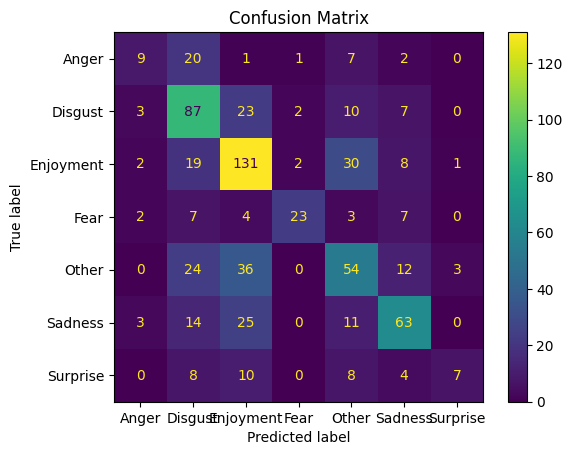

In [376]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Task 20: Phân tích Confusion Matrix
1. Lớp nào bị nhầm nhiều nhất?
2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
3. Tính precision/recall/F1 riêng từng lớp.
4. Đề xuất cách giảm lỗi của lớp yếu nhất.

# 21. Accuracy, Precision, Recall, F1

In [377]:
print(classification_report(y_test, best_pred, zero_division=0))

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="macro", zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="micro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, best_pred, average="weighted", zero_division=0
)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

              precision    recall  f1-score   support

       Anger       0.47      0.23      0.31        40
     Disgust       0.49      0.66      0.56       132
   Enjoyment       0.57      0.68      0.62       193
        Fear       0.82      0.50      0.62        46
       Other       0.44      0.42      0.43       129
     Sadness       0.61      0.54      0.58       116
    Surprise       0.64      0.19      0.29        37

    accuracy                           0.54       693
   macro avg       0.58      0.46      0.49       693
weighted avg       0.55      0.54      0.53       693

Macro F1   : 0.4859
Micro F1   : 0.5397
Weighted F1: 0.5296


## Task 21: Macro / Micro / Weighted
1. Tạo một dataset mất cân bằng.
2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.
4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?

# 22. ROC-AUC cho bài toán nhị phân

Ta chuyển sentiment thành:
- positive
- non-positive

Logistic Regression có `predict_proba`, phù hợp để minh họa ROC.

ROC-AUC: 1.0


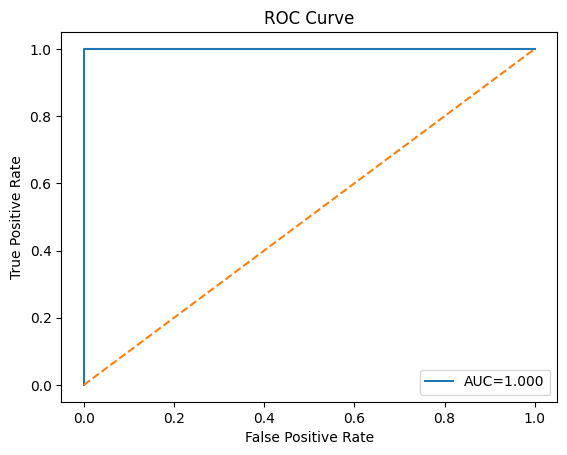

In [378]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df["text_norm"],
    df["binary_sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["binary_sentiment"]
)

binary_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])
binary_lr.fit(Xb_train, yb_train)

classes = list(binary_lr.named_steps["clf"].classes_)
pos_idx = classes.index("positive")
proba = binary_lr.predict_proba(Xb_test)[:, pos_idx]
y_true_binary = (yb_test == "positive").astype(int)

auc = roc_auc_score(y_true_binary, proba)
fpr, tpr, thresholds = roc_curve(y_true_binary, proba)

print("ROC-AUC:", round(auc, 4))

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Task 22: Threshold tuning
1. Không dùng mặc định threshold 0.5.
2. Thử threshold:
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.
3. Vẽ Precision/Recall theo threshold.
4. Chọn threshold phù hợp nếu:
   - false negative đắt hơn,
   - false positive đắt hơn.

In [379]:
# TODO: viết hàm evaluate_threshold(...)

# 23. Xử lý mất cân bằng

Các hướng:
- `class_weight`
- over-sampling
- under-sampling
- threshold tuning

Không được chỉ nhìn Accuracy.

In [380]:
# Tạo dữ liệu mất cân bằng minh họa
imbalanced = pd.concat([
    df[df.sentiment == "positive"],
    df[df.sentiment == "negative"].sample(10, random_state=RANDOM_STATE),
    df[df.sentiment == "neutral"].sample(8, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

print(imbalanced["sentiment"].value_counts())

sentiment
positive    40
negative    10
neutral      8
Name: count, dtype: int64


## Task 23: Imbalance
1. Train Logistic Regression:
   - không class weight,
   - `class_weight='balanced'`.
2. Tự viết random over-sampling.
3. Tự viết random under-sampling.
4. So sánh macro F1 và recall của lớp thiểu số.
5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.

In [381]:
def random_oversample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

def random_undersample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

# 24. Error Analysis theo chiều dài văn bản

In [382]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "gold": y_test.values,
    "pred": best_pred
})

error_df["n_words"] = error_df["text"].str.split().map(len)
error_df["correct"] = error_df["gold"] == error_df["pred"]

def length_bucket(n):
    if n <= 7:
        return "short"
    elif n <= 12:
        return "medium"
    else:
        return "long"

error_df["length_group"] = error_df["n_words"].map(length_bucket)

display(error_df.head())
print(error_df.groupby("length_group")["correct"].mean())

,text,gold,pred,n_words,correct,length_group
0,người ta có bạn bè nhìn vui thật,Sadness,Enjoyment,8,False,medium
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,Disgust,10,False,medium
2,kinh vãi 😡,Disgust,Disgust,3,True,short
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,Sadness,18,False,long
4,bố không thích nộp đấy mày thích ý kiến không,Anger,Disgust,10,False,medium


length_group
long      0.504823
medium    0.540816
short     0.596774
Name: correct, dtype: float64


## Task 24: Error analysis bắt buộc
Phân tích ít nhất **20 dự đoán sai** và gán nguyên nhân:

- negation,
- sarcasm,
- emoji,
- teencode,
- code-switching,
- domain-specific,
- ambiguous,
- too short,
- rare vocabulary,
- preprocessing issue,
- annotation issue.

Mỗi lỗi phải có:
- text,
- gold,
- prediction,
- nhóm nguyên nhân,
- giải thích,
- đề xuất cải tiến.

In [383]:
mistakes = error_df[~error_df["correct"]].copy()
display(mistakes.head(20))

# TODO: thêm cột "error_category", "analysis", "proposed_fix"

,text,gold,pred,n_words,correct,length_group
0,người ta có bạn bè nhìn vui thật,Sadness,Enjoyment,8,False,medium
1,cho nghỉ viêc mói đúng sao goi là kỷ luật,Surprise,Disgust,10,False,medium
3,nhà thì không xa lắm nhưng chưa bao giờ đi vì ...,Fear,Sadness,18,False,long
4,bố không thích nộp đấy mày thích ý kiến không,Anger,Disgust,10,False,medium
5,bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân...,Other,Sadness,15,False,long
9,per trình mày vẫn còn thấp chán =)),Other,Sadness,8,False,medium
10,mấy ai được như vậy ??,Other,Enjoyment,6,False,short
15,ổng quay thiệt mà sao chửi ổng thế . không qua...,Other,Surprise,18,False,long
18,sao lại cứ phải thế nhỉ,Other,Surprise,6,False,short
19,mệt vãi .. mà cừời cũng vãi ??????,Enjoyment,Disgust,8,False,medium


# 25. Bảng benchmark các baseline

In [384]:
models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
}

records = []

# rule based
pred = rule_pred
p, r, f, _ = precision_recall_fscore_support(
    y_test, pred, average="macro", zero_division=0
)
records.append({
    "model": "Rule-based",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f,
    "train_seconds": 0.0,
    "interpretability": "high"
})

for name, model in models.items():
    if model is None:
        continue
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f,
        "train_seconds": elapsed,
        "interpretability": (
            "medium-high" if "Logistic" in name or "NB" in name
            else "medium"
        )
    })

benchmark_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False)
display(benchmark_df)

,model,accuracy,macro_f1,train_seconds,interpretability
3,TFIDF + LinearSVM,0.548341,0.533928,0.228609,medium
2,TFIDF + Logistic,0.509380,0.428505,1.643031,medium-high
5,Random Forest,0.467532,0.425547,3.427270,medium
1,TFIDF + NB,0.401154,0.208242,0.165796,medium-high
4,Decision Tree,0.341991,0.198239,0.089299,medium
0,Rule-based,0.000000,0.000000,0.000000,high


## Task 25: Benchmark cải tiến
Bổ sung vào bảng:
- word unigram,
- word bigram,
- char n-gram,
- class weight,
- best tuned model,
- PhoBERT/ViSoBERT nếu chạy được.

Thêm:
- inference time / 1.000 câu,
- số feature / số parameter,
- kích thước model,
- mức độ giải thích.

# 26. PhoBERT / ViSoBERT — scaffold mở rộng

Phần này cần:
- Internet hoặc model đã tải sẵn,
- `transformers`,
- `datasets`,
- PyTorch,
- GPU nếu muốn fine-tune nhanh.

Mục tiêu:
- dùng cùng train/test split,
- fine-tune pretrained model,
- báo cáo cùng metric với baseline.

In [385]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    # Ví dụ scaffold — sinh viên hoàn thiện
    #
    # from transformers import (
    #     AutoTokenizer,
    #     AutoModelForSequenceClassification,
    #     TrainingArguments,
    #     Trainer
    # )
    #
    # MODEL_NAME = "vinai/phobert-base"
    # tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    #
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     MODEL_NAME,
    #     num_labels=3
    # )
    #
    # TODO:
    # 1. encode dataset
    # 2. map label -> id
    # 3. build Trainer
    # 4. fine-tune
    # 5. evaluate trên đúng test split
    #
    print("Transformer section enabled.")
else:
    print("Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.")

Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.


## Task 26: Pretrained model
Sinh viên chọn ít nhất một:
- PhoBERT
- ViSoBERT
- mô hình tiếng Việt tương đương được giảng viên chấp thuận.

Yêu cầu:
1. Fine-tune trên cùng split.
2. Báo cáo:
   - Accuracy,
   - Macro F1,
   - confusion matrix,
   - train time,
   - inference time.
3. Phân tích ít nhất 10 câu:
   - pretrained đúng nhưng baseline sai,
   - baseline đúng nhưng pretrained sai.
4. So sánh khả năng giải thích.

# 27. Bài so sánh

Sinh viên phải so sánh ít nhất:

### Hệ thống A
**TF-IDF + Naive Bayes**

### Hệ thống B
**TF-IDF + Logistic Regression hoặc Linear SVM**

### Hệ thống C
**PhoBERT hoặc ViSoBERT**

Dataset gợi ý:
- UIT-VSFC
- UIT-VSMEC
- sentiment / hate speech dataset tương đương

# 28. Yêu cầu cải tiến hệ thống

Ngoài ba hệ thống bắt buộc, nhóm phải thực hiện ít nhất **3 cải tiến** trong danh sách:

- [ ] word bigram / trigram
- [ ] character n-gram
- [ ] feature thủ công
- [ ] xử lý negation
- [ ] xử lý emoji
- [ ] xử lý teencode
- [ ] class weight
- [ ] oversampling
- [ ] threshold tuning
- [ ] hyperparameter tuning
- [ ] domain adaptation experiment
- [ ] ensemble
- [ ] custom preprocessing cho tiếng Việt

Mỗi cải tiến phải có:
1. giả thuyết/lý thuyết/phát biểu bài toán
2. thay đổi cụ thể,
3. metric trước,
4. metric sau,
5. giải thích kết quả.

# 29. Bài nộp

Notebook nộp phải có:

- [ ] Mô tả bài toán và label.
- [ ] Thống kê dataset.
- [ ] Train/validation/test split rõ ràng.
- [ ] TF-IDF + Naive Bayes.
- [ ] TF-IDF + Logistic Regression hoặc SVM.
- [ ] PhoBERT / ViSoBERT hoặc pretrained model tương đương.
- [ ] Confusion Matrix.
- [ ] Accuracy, Precision, Recall, F1.
- [ ] Macro / Micro / Weighted.
- [ ] Xử lý hoặc phân tích class imbalance.
- [ ] Ít nhất 20 failure cases được phân nhóm.
- [ ] So sánh training time.
- [ ] So sánh inference time.
- [ ] So sánh khả năng giải thích.
- [ ] Ít nhất 3 cải tiến so với baseline.

# 30. Bảng kết quả đề xuất

| Hệ thống | Representation | Accuracy | Macro F1 | Train time | Inference | Explainability |
|---|---|---:|---:|---:|---:|---|
| Rule-based | Lexicon | | | | | Cao |
| NB | TF-IDF | | | | | Cao |
| Logistic | TF-IDF | | | | | Khá cao |
| Linear SVM | TF-IDF | | | | | Khá |
| Improved Traditional | ... | | | | | ... |
| PhoBERT / ViSoBERT | Contextual Embedding | | | | | Thấp hơn |

### Câu hỏi bắt buộc
1. Mô hình nào tốt nhất theo Macro F1?
2. Mô hình nào nhanh nhất?
3. Mô hình nào dễ giải thích nhất?
4. Có đáng đổi tốc độ và khả năng giải thích để lấy thêm accuracy không?
5. Mô hình nào phù hợp nhất nếu triển khai CPU?

# 31. Rubric

| Thành phần | Điểm |
|---|---:|
| Dataset + split + chống leakage | 10 |
| Text representation | 15 |
| Naive Bayes baseline | 10 |
| Logistic/SVM baseline | 10 |
| Pretrained model | 15 |
| Evaluation đúng và đầy đủ | 15 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis ≥ 20 cases | 10 |
| Trình bày + kết luận | 5 |
| **Tổng** | **100** |

### Điểm cộng
- Aspect-based sentiment
- Domain adaptation
- Robustness test với teencode / typo / emoji
- Calibration / threshold tuning
- Ensemble